Here is a common machine learning workflow using scikit-learn to train and tune a Random Forest classifier, with a specific focus on optimizing the False Negative Rate (FNR). This is particularly relevant in domains like medical diagnosis (e.g., breast cancer detection) where missing a positive case (a false negative) can have severe consequences.

In [2]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report,make_scorer
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    LeaveOneOut,
    KFold,
    StratifiedKFold
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_breast_cancer

In [3]:
x,y  = load_breast_cancer(return_X_y = True,as_frame = True)
y = y.map({1:0,0:1})
x.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Original Labels: In the load_breast_cancer dataset, the target labels are 0 for malignant (cancerous) and 1 for benign (non-cancerous).

y = y.map({1:0, 0:1}):

This line re-maps the target labels.

Original 1 (benign) becomes new 0.

Original 0 (malignant) becomes new 1.

the FNR calculated later will specifically tell us the rate at which malignant tumors were incorrectly classified as benign (missed diagnoses), which is a critical error in this context.

In [4]:
y.value_counts()/len(y)

target
0    0.627417
1    0.372583
Name: count, dtype: float64

In [13]:
def fnr(y_true,y_pred):
    tn,fp,fn,tp = confusion_matrix(y_true,y_pred).ravel()
    FNR = fn/(tp+fn)
    return FNR

fnr_score = make_scorer(fnr,greater_is_better = False,response_method = 'predict')

FNR is the proportion of actual positive instances that the model failed to detect. In our re-mapped breast cancer dataset, this is the proportion of malignant tumors that were predicted as benign. This is also known as the "Miss Rate" or "Type II Error Rate." A lower FNR is highly desirable in medical screening.



In [14]:
rf_model = RandomForestClassifier(n_estimators = 100,max_depth = 1,random_state = 0,n_jobs = 4)

In [15]:
rf_param_grid = dict(
    n_estimators = [10,20,50,100,200,500,1000,2000],
    max_depth = [1,2,3,4]
)

In [16]:
clf = GridSearchCV(rf_model,rf_param_grid,scoring=fnr_score,cv = 5)

In [17]:
search = clf.fit(x,y)
search.best_params_

{'max_depth': 3, 'n_estimators': 200}

search = clf.fit(x, y): This is the core step where the hyperparameter tuning process begins. GridSearchCV will:

Iterate through every combination of n_estimators and max_depth defined in rf_param_grid.

For each combination, perform 5-fold cross-validation.

Train a rf_model on the training folds and make predictions on the validation fold.

Calculate the fnr_score for the validation fold.

Record all these scores.

After evaluating all combinations, it selects the combination that yields the lowest mean_test_score (because greater_is_better=False for FNR).

search.best_params_: After fit() completes, this attribute of the GridSearchCV object will hold a dictionary containing the combination of n_estimators and max_depth that resulted in the best (lowest FNR) average score across all cross-validation folds.

In [ ]:
result = pd.DataFrame(search.cv_results_)[['params','mean_test_score','std_test_score']]
print(result.shape)
print(result.head())

(32, 3)
                                  params  mean_test_score  std_test_score
0   {'max_depth': 1, 'n_estimators': 10}        -0.164563        0.068712
1   {'max_depth': 1, 'n_estimators': 20}        -0.159801        0.073267
2   {'max_depth': 1, 'n_estimators': 50}        -0.178627        0.068895
3  {'max_depth': 1, 'n_estimators': 100}        -0.145404        0.085822
4  {'max_depth': 1, 'n_estimators': 200}        -0.140642        0.082462


pd.DataFrame(search.cv_results_): The search.cv_results_ attribute is a dictionary that contains detailed results for all parameter settings tested during the grid search. This line converts that dictionary into a pandas DataFrame, making it easy to inspect.

[['params', 'mean_test_score', 'std_test_score']]: This selects specific columns from the DataFrame:

'params': A dictionary representing the hyperparameter combination for that row (e.g., {'n_estimators': 10, 'max_depth': 1}).

'mean_test_score': The average fnr_score obtained for that parameter combination across all 5 cross-validation folds. Since greater_is_better=False, the lowest value in this column indicates the best performance.

'std_test_score': The standard deviation of the fnr_score across the 5 folds for that combination, indicating the variability or stability of the score.

Text(0.5, 0, 'Hyperparameter Space')

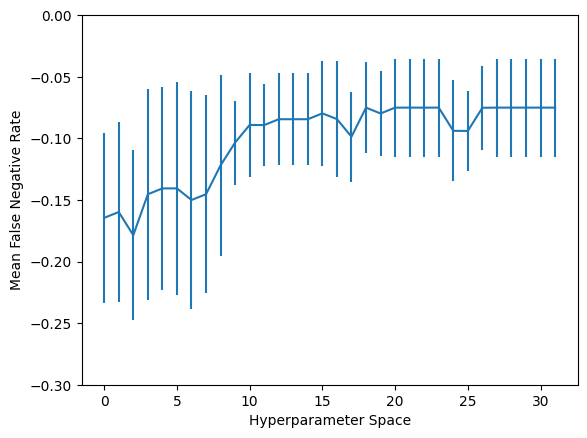

In [22]:
import matplotlib.pyplot as plt
result['mean_test_score'].plot(yerr= [result['std_test_score'], result['std_test_score']], subplots=True)
plt.ylim(-0.3,0)
plt.ylabel('Mean False Negative Rate')
plt.xlabel('Hyperparameter Space')

import matplotlib.pyplot as plt: Imports the matplotlib library for plotting.

result['mean_test_score'].plot(...): This directly plots the mean_test_score column from the result DataFrame.

yerr=[result['std_test_score'], result['std_test_score']]: This adds error bars to each data point on the plot. The error bars represent the standard deviation of the FNR across the cross-validation folds, giving an indication of the score's consistency.

subplots=True: This argument ensures the plot is created within its own subplot, which is often good practice but might not be strictly necessary for a single plot here.

plt.ylim(-0.3, 0): This sets the y-axis limits for the plot. Since greater_is_better=False, GridSearchCV internally might store negated scores. By setting ylim to a negative range (e.g., -0.3 to 0), it allows visualization of FNR values that are typically between 0 and 1, but represented as negative for minimization. Important: If GridSearchCV always returns positive scores (and just internally sorts by lowest), then this ylim might look odd; it's generally good to inspect mean_test_score values first to confirm their range before setting ylim. If your FNR can be 0.1, it might be displayed as -0.1 on the plot due to greater_is_better=False.

In [26]:
# FNR = fn / (tp+fn)
def fnr(y_true, y_pred):
    y_pred_class = np.where(y_pred > 0.37, 1,0)
    tn, fp, fn, tp = confusion_matrix(y_true,y_pred_class,labels=[0,1]).ravel()
    FNR = fn / (tp+fn)
    return FNR
fnr_score = make_scorer(fnr,greater_is_better=False,response_method='predict_proba')

In [27]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=1, random_state=0,n_jobs=4)
rf_param_grid = dict(
    n_estimators=[10,20,50,100,200,500,1000,2000],
    max_depth = [1,2,3,4]
)
clf = GridSearchCV(rf_model,rf_param_grid,scoring=fnr_score,cv=5)
search = clf.fit(x,y)
search.best_params_

{'max_depth': 4, 'n_estimators': 500}

Text(0.5, 0, 'Hyperparameter Space')

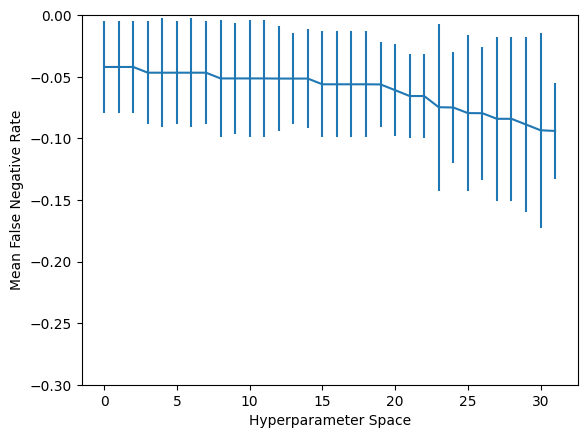

In [28]:
results = pd.DataFrame(search.cv_results_) [['params','mean_test_score', 'std_test_score']]
results.head()
results.sort_values(by='mean_test_score', ascending=False,inplace=True)
results.reset_index(drop=True, inplace=True)
results['mean_test_score'].plot(yerr= [results['std_test_score'], results['std_test_score']], subplots=True)
plt.ylim(-0.3,0)
plt.ylabel('Mean False Negative Rate')
plt.xlabel('Hyperparameter Space')